In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from datetime import datetime, timedelta

from core.ml.price.backtest import BacktestEngine, plot_strategy_vs_benchmark
from core.portfolio.asset import Portfolio
from core.data.instrument.provider import InstrumentProvider
from core.data.instrument.instrument import Instrument
from core.ml.price.modelalt import PriceDirPredictorLGBM, PriceDirPredictorXGB
from core.ml.price.strategy import ATRStopLossStrategy

ip = InstrumentProvider()
instrument: Instrument = ip.get_instrument('NVDA')

HORIZON = 10

predictor = PriceDirPredictorXGB(instrument=instrument, horizon_days=HORIZON)
strategy = ATRStopLossStrategy(predictor)

portfolio = Portfolio('BT1', 'PLN')
start_date = datetime(2025, 1, 1)
engine = BacktestEngine(portfolio, start_date, strategy, initial_cash=1000.0)


print("--- Backtest ---")
reached_present = False
i = 0
while not reached_present:
    reached_present = engine.next_day()
    print(f"Day {i+1} ({engine.date.strftime('%Y-%m-%d')}): Assets Value: ${engine.assets_values:,.2f}, Cash: ${engine.cash}, Total Value: ${engine.total_value}")
    i += 1

engine.show_transaction_log_df()

--- Backtest ---
Day 1 (2026-01-02): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 2 (2026-01-03): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 3 (2026-01-04): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 4 (2026-01-05): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 5 (2026-01-06): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 6 (2026-01-07): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 7 (2026-01-08): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 8 (2026-01-09): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 9 (2026-01-10): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 10 (2026-01-11): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 11 (2026-01-12): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 12 (2026-01-13): Assets Value: $0.00, Cash: $1000.0, Total Value: $1000.0
Day 13 (2026-01-14): Assets Value: $0.00, Cash: $1000.0,

Type,Symbol,Volume,Price ($),Total Amount ($),Fee ($)
BUY,MIL.WA,35.234611,16.20,570.80,0.00


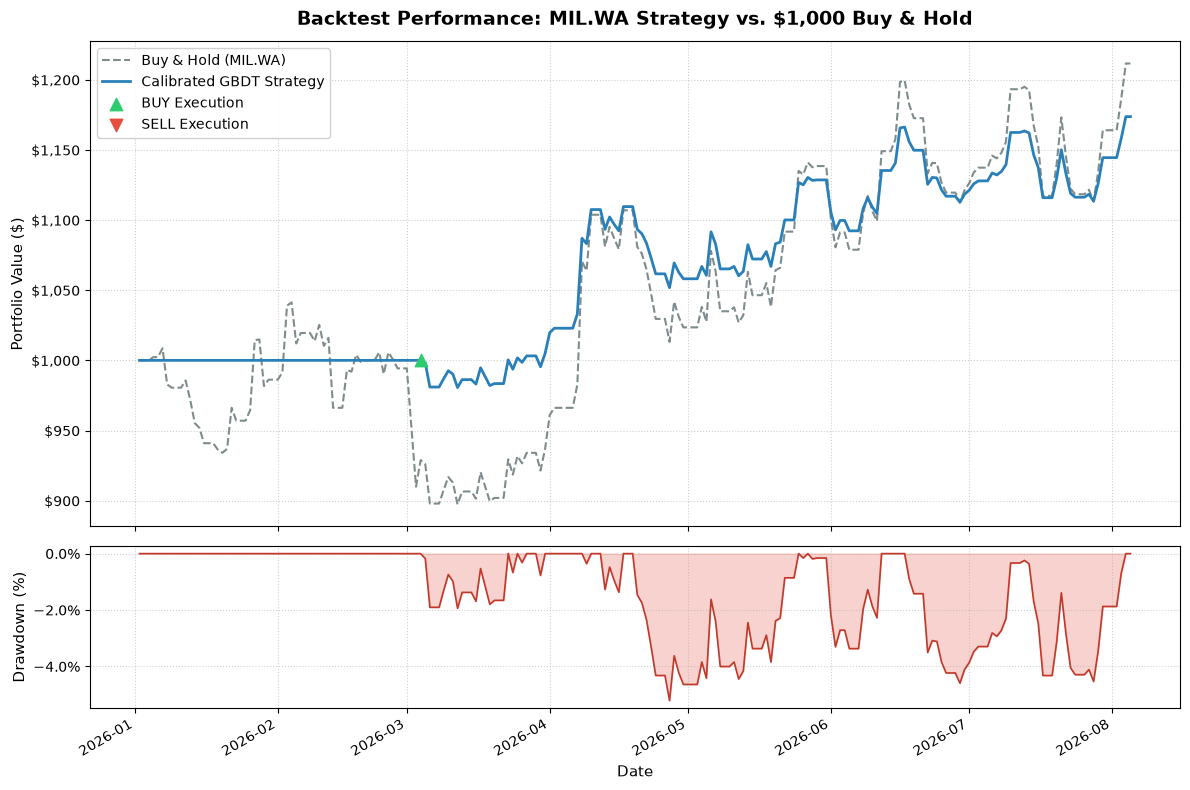

In [2]:
plot_strategy_vs_benchmark(engine, instrument)